# Reading the saved dictionary

In [62]:
import pickle
#new_dict.pkl is for training set
#new_dict_val.pkl is for validation set
with open('pascal_val.pkl', 'rb') as f:
    supp_dict = pickle.load(f)

In [ ]:
# these keys are not present in this dict (in training support)
# ignore_keys = [0, 1, 2, 3, 4, 5, 10, 11, 26, 27, 28, 29, 32, 33, 34, 37, 55, 59, 70, 75, 78, 80, 81, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 112, 113]

In [2]:
len(supp_dict) #for validation, 81 number of parts so 81 + 35 = 116 and 

81

In [3]:
supp_dict[6].keys()

dict_keys(['image_name', 'image', 'obj_id', 'obj_mask', 'part_id', 'part_mask'])

In [4]:
supp_dict[6]['image_name'], supp_dict[6]['obj_id'], supp_dict[6]['part_id']

('2008_000725', 1, 6)

## Visualizing the Supports kept in supp_dict

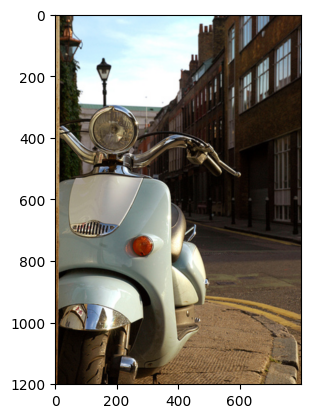

In [11]:
import matplotlib.pyplot as plt

plt.imshow(supp_dict[79]['image'][:, :, [2,1,0]])


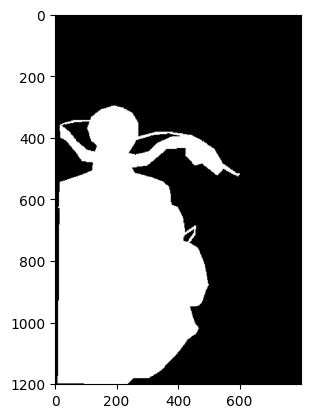

In [12]:
plt.imshow(supp_dict[79]['obj_mask'], cmap='gray')

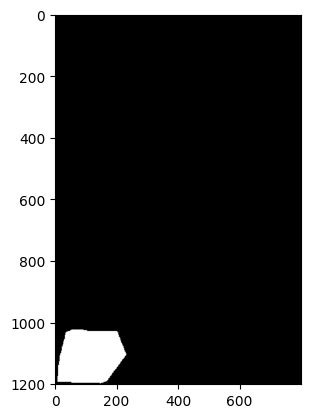

In [13]:
plt.imshow(supp_dict[79]['part_mask'], cmap='gray')

# Reading the query set from training_data

In [14]:
import os 
# root_dir, dataset_root
root_dir = "data/testing_data_pascal_MOHAN"
#root_dir = "data/testing_data_MOHAN"

folder_names = os.listdir(root_dir)
len(folder_names)

415

In [15]:
folder_paths = [os.path.join(root_dir, folder) for folder in folder_names]
len(folder_paths)

415

In [29]:
folder_path = folder_paths[414]
folder_name = os.path.basename(folder_path)
folder_name

'2008_000630_14_86'

In [30]:
parts = folder_name.split('_')
object_id = int(parts[-2])
part_id = int(parts[-1])
parts, object_id, part_id

(['2008', '000630', '14', '86'], 14, 86)

In [31]:
import matplotlib.pyplot as plt

In [32]:
from PIL import Image
# Load image and masks
query_image = Image.open(os.path.join(folder_path, 'image.jpg')).convert("RGB")
query_full_mask = Image.open(os.path.join(folder_path, 'object_mask.png')).convert("L")
query_part_mask = Image.open(os.path.join(folder_path, 'part_mask.png')).convert("L")

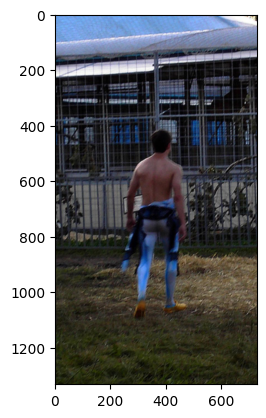

In [33]:
plt.imshow(query_image)

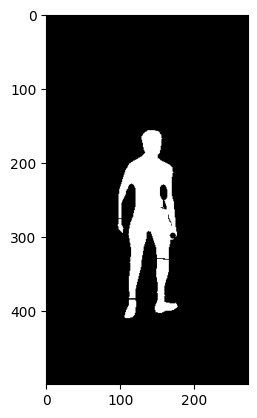

In [34]:
plt.imshow(query_full_mask, cmap='gray')

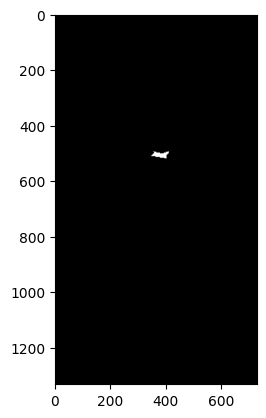

In [35]:
plt.imshow(query_part_mask, cmap='gray')

# Writin the above code for all the data with class

In [63]:
from torch.utils.data import DataLoader
from dataset import PartQueryDataset, custom_transform

# root directory pointing to training_data
dataset_root = "data/testing_data_pascal_MOHAN"


# supp_dict is defined above

dataset = PartQueryDataset(root_dir=dataset_root, supp_dict=supp_dict, transform=custom_transform)
#with now transform applied
#dataset = PartQueryDataset(dataset_root, supp_dict)

len(dataset)

358

In [64]:
dataset[0].keys()

dict_keys(['query_image', 'query_full_mask', 'query_part_mask', 'object_id', 'part_id', 'support_image', 'support_full_mask', 'support_part_mask'])

In [65]:
import matplotlib.pyplot as plt

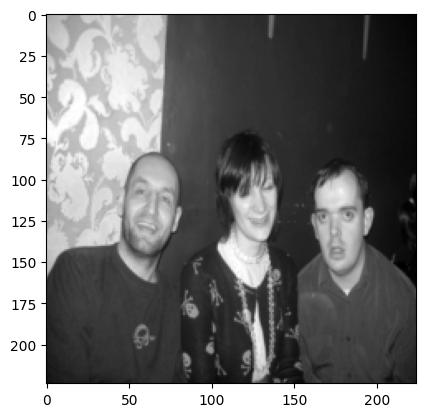

In [66]:
# when now transform applied then call below because it return tensor
#plt.imshow(dataset[0]['query_image'].permute(1, 2, 0).cpu().numpy())

#when transform used, use below code as it returns numpy of shape 224*224
plt.imshow(dataset[0]['query_image'], cmap='gray')

In [68]:
dataset[0]['query_full_mask'].shape, type(dataset[357]['query_full_mask'])

((224, 224), numpy.ndarray)

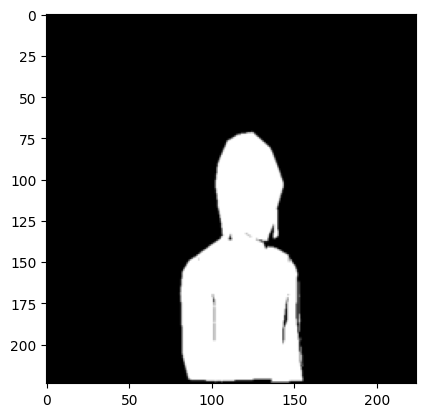

In [69]:
#use when no transform is applied
#plt.imshow(dataset[0]['query_full_mask'].squeeze(0), cmap='gray')

plt.imshow(dataset[0]['query_full_mask'], cmap='gray')

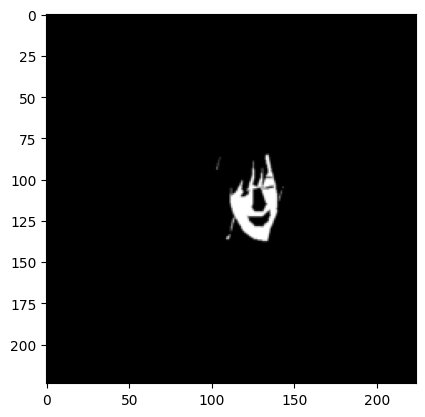

In [70]:
# plt.imshow(dataset[0]['query_part_mask'].squeeze(0), cmap='gray')

plt.imshow(dataset[0]['query_part_mask'], cmap='gray')

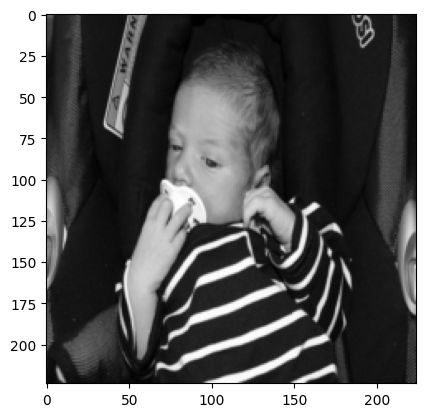

In [71]:
# here the image is not a tensor it is an mumpy array so just use this [2, 1, 0] to convert from BGR to RGB
# how ever use this when no transform is applied
# plt.imshow(dataset[0]['support_image'][:, :, [2, 1, 0]])

plt.imshow(dataset[0]['support_image'], cmap='gray')

In [73]:
dataset[357]['support_full_mask'].shape, type(dataset[357]['support_full_mask'])

((224, 224), numpy.ndarray)

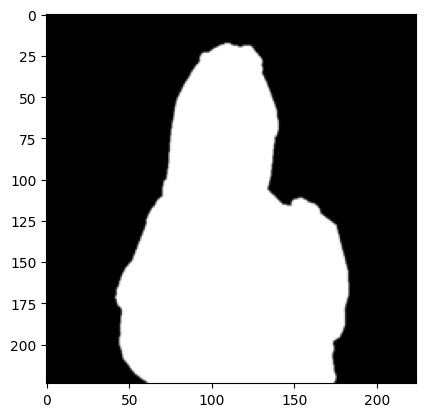

In [74]:
plt.imshow(dataset[0]['support_full_mask'], cmap='gray')

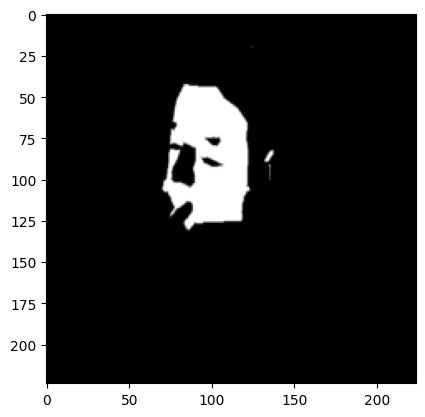

In [75]:
plt.imshow(dataset[0]['support_part_mask'], cmap='gray')

In [29]:
# below code is to check if max of my mask is at 0 or not
# Get unique values and their counts
# import numpy as np
# unique_values, counts = np.unique(dataset[0]['support_full_mask'], return_counts=True)

# # Display results
# count_all = 0
# for value, count in zip(unique_values, counts):
#     print(f"Value {value} occurs {count} times.")
#     count_all += 1

# print(count_all)

In [76]:
len(supp_dict)

81

In [78]:
dataloader = DataLoader(dataset, batch_size=8, shuffle=False, num_workers=8)

In [79]:
# now i have support and query
# Iterate over data
for batch in dataloader:
    print("Query image shape:", batch["query_image"].shape)            # (BS, 224, 224)
    print("Support image shape:", batch["support_image"].shape)        # (BS, 224, 224)
    print("Object ID:", batch["object_id"])
    print("Part ID:", batch["part_id"])
    break  # just show one for now

Exception ignored in: Exception ignored in: Exception ignored in: Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x71416c92edc0><function _MultiProcessingDataLoaderIter.__del__ at 0x71416c92edc0><function _MultiProcessingDataLoaderIter.__del__ at 0x71416c92edc0>


<function _MultiProcessingDataLoaderIter.__del__ at 0x71416c92edc0>Traceback (most recent call last):
Traceback (most recent call last):

Traceback (most recent call last):
  File "/home/iiitb/anaconda3/envs/SuperPixels/lib/python3.9/site-packages/torch/utils/data/dataloader.py", line 1479, in __del__
  File "/home/iiitb/anaconda3/envs/SuperPixels/lib/python3.9/site-packages/torch/utils/data/dataloader.py", line 1479, in __del__
Traceback (most recent call last):
  File "/home/iiitb/anaconda3/envs/SuperPixels/lib/python3.9/site-packages/torch/utils/data/dataloader.py", line 1479, in __del__
      File "/home/iiitb/anaconda3/envs/SuperPixels/lib/python3.9/site-packages/torch/utils/data/dataloader.py"

Query image shape: torch.Size([8, 224, 224])
Support image shape: torch.Size([8, 224, 224])
Object ID: tensor([14, 14, 14, 14, 14, 14, 11, 14])
Part ID: tensor([83, 94, 94, 92, 84, 89, 67, 90])


In [80]:
batch['query_part_mask'].shape

torch.Size([8, 224, 224])

# getting the features for query and affinity matrix

In [81]:
from part_seg import get_query_feature_and_affinity_matrix
import numpy as np
import os

In [82]:
# Ensure the directory exists
output_dir = './saved_features'
os.makedirs(output_dir, exist_ok=True)

In [ ]:
# argument passing sequence
#support_image, support_mask, support_full_mask, query_image, query_full_mask, query_part_mask

In [84]:
# for single batch_size
count = 0
for batch in dataloader:

    # the below code is to get the 11th item
    if count == 0:
        count += 1
        continue
       
    for i in range(len(batch['query_image'])):
        query_dict, support_dict, query_full_superpixels, support_part_superpixels, gt_query_part_superpixels, cos_mat_dist = get_query_feature_and_affinity_matrix(batch["support_image"][i], batch["support_part_mask"][i], 
                                                                                                     batch["support_full_mask"][i], 
                                                                                                     batch["query_image"][i], batch["query_part_mask"][i], 
                                                                                                     batch["query_full_mask"][i])
        
        # Save the outputs
        save_path = f"./saved_features/item_{i+11_2}.npz"
        np.savez_compressed(save_path, 
                            query_dict=query_dict, 
                            support_dict=support_dict,
                            query_full_superpixels=query_full_superpixels,
                            support_part_superpixels=support_part_superpixels,
                            gt_query_part_superpixels=gt_query_part_superpixels, 
                            cos_mat_dist=cos_mat_dist)
        
        print(f"Saved features to {save_path}")
        
        break # just to print one element in the batch
        
    break #to just print first batch

Saved features to ./saved_features/item_112.npz


In [85]:
query_dict['original_image'].shape, query_dict['superpixel_overlayed'].shape, query_dict['superpixel_labels'].shape, query_dict['superpixel_features'].shape

((224, 224, 3), (224, 224, 3), (224, 224), (784, 1024))

In [86]:
support_dict['original_image'].shape, support_dict['superpixel_overlayed'].shape, support_dict['superpixel_labels'].shape, support_dict['superpixel_features'].shape

((224, 224, 3), (224, 224, 3), (224, 224), (784, 1024))

In [87]:
import numpy as np
len(np.unique(query_dict['superpixel_labels'])) #784 is the number of superpixel our entire image is divided into

784

In [88]:
import numpy as np
len(np.unique(support_dict['superpixel_labels']))

784

In [89]:
len(query_full_superpixels), type(query_full_superpixels), cos_mat_dist.shape

(336, numpy.ndarray, (336, 40))

In [90]:
len(support_part_superpixels), type(support_part_superpixels), cos_mat_dist.shape

(40, numpy.ndarray, (336, 40))

In [91]:
len(gt_query_part_superpixels), type(gt_query_part_superpixels), cos_mat_dist.shape

(39, numpy.ndarray, (336, 40))

In [92]:
# pick only superpixel belonging to query object
query_dict['superpixel_features'][query_full_superpixels].shape

(336, 1024)

In [93]:
query_full_superpixels

array([141, 143, 144, 145, 146, 147, 148, 149, 152, 153, 168, 169, 170,
       171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183,
       184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 196, 197,
       198, 199, 200, 201, 202, 203, 204, 205, 206, 207, 208, 209, 210,
       211, 212, 213, 214, 215, 216, 217, 218, 219, 220, 221, 222, 223,
       224, 225, 226, 227, 228, 229, 230, 231, 232, 233, 234, 235, 236,
       237, 238, 239, 240, 241, 242, 243, 244, 245, 246, 247, 248, 249,
       250, 251, 252, 253, 254, 255, 256, 257, 258, 259, 260, 261, 262,
       263, 264, 265, 266, 267, 268, 269, 270, 271, 272, 273, 274, 275,
       276, 277, 278, 279, 280, 281, 282, 283, 284, 285, 286, 287, 288,
       289, 290, 291, 292, 293, 294, 295, 296, 297, 298, 299, 300, 301,
       302, 303, 304, 305, 306, 307, 308, 309, 310, 311, 312, 313, 314,
       315, 316, 317, 318, 319, 320, 321, 322, 323, 324, 325, 326, 327,
       328, 329, 330, 331, 332, 333, 334, 335, 336, 337, 338, 33

In [94]:
support_part_superpixels

array([141, 143, 144, 168, 169, 170, 171, 196, 198, 199, 224, 227, 252,
       283, 311, 337, 338, 339, 364, 365, 366, 367, 392, 393, 394, 420,
       421, 422, 423, 424, 448, 449, 450, 451, 476, 477, 478, 505, 506,
       507], dtype=int32)

In [95]:
gt_query_part_superpixels

array([141, 143, 168, 169, 170, 171, 196, 199, 224, 226, 227, 252, 255,
       283, 311, 337, 338, 364, 365, 366, 367, 392, 393, 394, 420, 421,
       422, 423, 448, 449, 450, 451, 476, 477, 478, 479, 505, 506, 507],
      dtype=int32)

In [ ]:
# we can load .npz file from ./saved_features and can work on it.
# for graph Data, we need to further make it in Graph structure that is done in image2graph.ipynb and img2graph.py

# below code is compatible for batch

In [101]:
batch_count = 0
for batch in dataloader:
    batch_count += 1
    gt_output_list = []
    real_sups_seg_list = []
    cos_mat_dist_list = []

    for i in range(len(batch["query_image"])):
        query_dict, support_dict, query_full_superpixels, support_part_superpixels, gt_query_part_superpixels, cos_mat_dist = get_query_feature_and_affinity_matrix(
            batch["support_image"][i], batch["support_part_mask"][i],
            batch["support_full_mask"][i], batch["query_image"][i],
            batch["query_part_mask"][i], batch["query_full_mask"][i]
        )
        print(f"For batch no {batch_count} the {i}th elements:")
        print(query_dict['original_image'].shape, query_dict['superpixel_overlayed'].shape, query_dict['superpixel_labels'].shape, query_dict['superpixel_features'].shape)
        print(len(query_full_superpixels), cos_mat_dist.shape)
        print(len(support_part_superpixels), cos_mat_dist.shape)
        print(len(gt_query_part_superpixels), cos_mat_dist.shape)
        print(query_dict['superpixel_features'][query_full_superpixels].shape)
        print("\n")


        gt_output_list.append(query_dict)
        real_sups_seg_list.append(query_full_superpixels)
        cos_mat_dist_list.append(cos_mat_dist)

    #break  # testing only the first batch

    if batch_count == 2:
        break

    # need to write the code to save all batches above one just appended images in a batch



For batch no 1 the 0th elements:
(224, 224, 3) (224, 224, 3) (224, 224) (784, 1024)
159 (159, 82)
82 (159, 82)
35 (159, 82)
(159, 1024)


For batch no 1 the 1th elements:
(224, 224, 3) (224, 224, 3) (224, 224) (784, 1024)
76 (76, 91)
91 (76, 91)
9 (76, 91)
(76, 1024)


For batch no 1 the 2th elements:
(224, 224, 3) (224, 224, 3) (224, 224) (784, 1024)
8 (8, 91)
91 (8, 91)
2 (8, 91)
(8, 1024)


For batch no 1 the 3th elements:
(224, 224, 3) (224, 224, 3) (224, 224) (784, 1024)
76 (76, 6)
6 (76, 6)
4 (76, 6)
(76, 1024)


For batch no 1 the 4th elements:
(224, 224, 3) (224, 224, 3) (224, 224) (784, 1024)
103 (103, 10)
10 (103, 10)
2 (103, 10)
(103, 1024)


For batch no 1 the 5th elements:
(224, 224, 3) (224, 224, 3) (224, 224) (784, 1024)
77 (77, 10)
10 (77, 10)
2 (77, 10)
(77, 1024)


For batch no 1 the 6th elements:
(224, 224, 3) (224, 224, 3) (224, 224) (784, 1024)
133 (133, 20)
20 (133, 20)
18 (133, 20)
(133, 1024)


For batch no 1 the 7th elements:
(224, 224, 3) (224, 224, 3) (224, 2

In [102]:
real_sups_seg_list[0], len(real_sups_seg_list[0])

(array([141, 143, 144, 145, 146, 147, 148, 149, 152, 153, 168, 169, 170,
        171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183,
        184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 196, 197,
        198, 199, 200, 201, 202, 203, 204, 205, 206, 207, 208, 209, 210,
        211, 212, 213, 214, 215, 216, 217, 218, 219, 220, 221, 222, 223,
        224, 225, 226, 227, 228, 229, 230, 231, 232, 233, 234, 235, 236,
        237, 238, 239, 240, 241, 242, 243, 244, 245, 246, 247, 248, 249,
        250, 251, 252, 253, 254, 255, 256, 257, 258, 259, 260, 261, 262,
        263, 264, 265, 266, 267, 268, 269, 270, 271, 272, 273, 274, 275,
        276, 277, 278, 279, 280, 281, 282, 283, 284, 285, 286, 287, 288,
        289, 290, 291, 292, 293, 294, 295, 296, 297, 298, 299, 300, 301,
        302, 303, 304, 305, 306, 307, 308, 309, 310, 311, 312, 313, 314,
        315, 316, 317, 318, 319, 320, 321, 322, 323, 324, 325, 326, 327,
        328, 329, 330, 331, 332, 333, 334, 335, 336

In [103]:
len(gt_output_list), len(real_sups_seg_list), len(cos_mat_dist_list)

(8, 8, 8)

In [ ]:
# consider these two query_superpixel_features.shape, affinity_matrix.shape and form the graph
